# Surface Code: Noisy Simulation with Decoding

This notebook demonstrates:
1. Noiseless surface code memory experiments
2. Noisy simulations with depolarizing noise
3. Raw logical error rate measurement (no decoding)
4. Decoding using multiple Rust-wrapped backends
5. Comparison of raw vs decoded error rates
6. PECOS native Detector Error Model (DEM) generation
7. Unified circuit generation (Guppy, TickCircuit, DagCircuit)

**Available Decoders** (all via Rust bindings in `pecos_rslib.decoders`):
- **PyMatching** (default): Fast C++ MWPM decoder
- **FusionBlossom**: Pure Rust MWPM decoder
- **BP+OSD**: Belief Propagation + Ordered Statistics Decoding
- **BP+LSD**: Belief Propagation + Localized Statistics Decoding
- **UnionFind**: Cluster-based decoder

**Key concept**: The surface code threshold (~1%) only manifests with proper decoding.
Without a decoder, larger codes have more qubits that can be corrupted.

In [1]:
import numpy as np
from pecos.compilation_pipeline import compile_guppy_to_hugr
from pecos.guppy.surface import get_num_qubits, make_surface_code
from pecos.qec.surface import (
    NoiseModel,
    SurfaceDecoder,
    SurfacePatch,
    plot_surface_code,
)
from selene_sim import DepolarizingErrorModel, IdealErrorModel, SimpleRuntime, Stim, build

## Configuration

In [2]:
NUM_ROUNDS = 1  # Syndrome extraction rounds
NUM_SHOTS = 500  # Shots per experiment
BASIS = "Z"  # Memory experiment basis

## Helper Functions

In [ ]:
from typing import Any


def get_logical_qubits(distance: int, basis: str) -> tuple:
    """Get qubits in the logical operator."""
    patch = SurfacePatch.create(distance=distance)
    if basis == "Z":
        return patch.geometry.logical_z.data_qubits
    return patch.geometry.logical_x.data_qubits


def run_memory_experiment(
    distance: int,
    num_rounds: int,
    num_shots: int,
    basis: str,
    error_model: Any,
    *,
    decode: bool = False,
    decoder_type: str = "pymatching",
) -> dict:
    """Run memory experiment and compute logical error rate.

    For Z-basis: prepare |0_L>, measure in Z basis, check logical Z parity.
    For X-basis: prepare |+_L>, measure in X basis, check logical X parity.

    Args:
        distance: Code distance
        num_rounds: Number of syndrome extraction rounds
        num_shots: Number of shots to run
        basis: 'Z' or 'X' basis
        error_model: Selene error model (IdealErrorModel or DepolarizingErrorModel)
        decode: If True, use decoding to correct errors
        decoder_type: Decoder backend ('pymatching', 'fusion_blossom', 'bp_osd', 'bp_lsd', 'union_find', 'tesseract')

    Returns:
        Dictionary with experiment results
    """
    patch = SurfacePatch.create(distance=distance)
    logical_qubits = get_logical_qubits(distance, basis)

    # Create decoder if needed
    decoder = None
    if decode:
        # Extract noise parameters from error model
        noise = NoiseModel(
            p1=getattr(error_model, "p_1q", 0.01),
            p2=getattr(error_model, "p_2q", 0.01),
            p_meas=getattr(error_model, "p_meas", 0.01),
            p_prep=getattr(error_model, "p_init", 0.01),
        )
        decoder = SurfaceDecoder(patch, num_rounds=num_rounds, noise=noise, decoder_type=decoder_type)

    # Build circuit
    num_qubits = get_num_qubits(distance)
    prog = make_surface_code(distance=distance, num_rounds=num_rounds, basis=basis)
    hugr_bytes = compile_guppy_to_hugr(prog)
    instance = build(hugr_bytes, name=f"surface_d{distance}")

    # Run
    num_logical_errors = 0
    num_raw_errors = 0

    for shot_results in instance.run_shots(
        simulator=Stim(),
        n_qubits=num_qubits,
        n_shots=num_shots,
        error_model=error_model,
        runtime=SimpleRuntime(),
        n_processes=1,
    ):
        # Collect all syndromes properly (multiple entries per key)
        synx_list = []
        synz_list = []
        final = None

        for name, values in shot_results:
            vals = list(values)
            if name == "synx":
                synx_list.append(np.array(vals, dtype=np.uint8))
            elif name == "synz":
                synz_list.append(np.array(vals, dtype=np.uint8))
            elif name == "final":
                final = vals

        if final is None:
            continue

        # Raw parity check (no decoding)
        raw_parity = sum(final[q] for q in logical_qubits) % 2
        if raw_parity != 0:
            num_raw_errors += 1

        if decode and decoder is not None:
            final_arr = np.array(final, dtype=np.uint8)

            # Decode based on basis
            if basis == "Z":
                is_error, _ = decoder.decode_memory_z(synx_list, synz_list, final_arr)
            else:
                is_error, _ = decoder.decode_memory_x(synx_list, synz_list, final_arr)

            if is_error:
                num_logical_errors += 1
        else:
            # No decoding - use raw parity
            if raw_parity != 0:
                num_logical_errors += 1

    return {
        "distance": distance,
        "num_shots": num_shots,
        "num_logical_errors": num_logical_errors,
        "num_raw_errors": num_raw_errors,
        "logical_error_rate": num_logical_errors / num_shots,
        "raw_error_rate": num_raw_errors / num_shots,
        "decoded": decode,
        "decoder_type": decoder_type if decode else None,
    }

## Surface Code Visualization

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for _i, d in enumerate([3, 5, 7]):
    fig_d, ax_d = plot_surface_code(d, show_cnot_order=False)
    ax_d.set_title(f"Distance {d}", fontsize=12)
    fig_d.show()

## Part 1: Noiseless Verification

Verify the circuit works correctly with no noise.

In [5]:
print("=== Noiseless Verification ===")
print()

for d in [3, 5, 7]:
    result = run_memory_experiment(
        distance=d,
        num_rounds=NUM_ROUNDS,
        num_shots=100,
        basis=BASIS,
        error_model=IdealErrorModel(),
    )
    print(f"d={d}: {result['num_logical_errors']}/{result['num_shots']} errors "
          f"(LER = {result['logical_error_rate']:.4f})")

=== Noiseless Verification ===



d=3: 0/100 errors (LER = 0.0000)


d=5: 0/100 errors (LER = 0.0000)


d=7: 0/100 errors (LER = 0.0000)


## Part 2: Noisy Simulation

Add depolarizing noise and measure logical error rates.
The depolarizing model applies:
- Single-qubit errors after 1Q gates
- Two-qubit errors after 2Q gates  
- Measurement errors
- Initialization errors

In [6]:
distances = [3, 5, 7]
error_rates = [0.001, 0.002, 0.005, 0.01, 0.02, 0.05, 0.1]

results = []

print("=== Noisy Simulation ===")
for d in distances:
    print(f"\nDistance {d}:")
    for p in error_rates:
        error_model = DepolarizingErrorModel(
            p_1q=p, p_2q=p, p_meas=p, p_init=p,
        )

        result = run_memory_experiment(
            distance=d,
            num_rounds=NUM_ROUNDS,
            num_shots=NUM_SHOTS,
            basis=BASIS,
            error_model=error_model,
        )

        results.append((d, p, result["logical_error_rate"]))
        print(f"  p={p:.3f}: LER={result['logical_error_rate']:.3f} "
              f"({result['num_logical_errors']}/{NUM_SHOTS})")

=== Noisy Simulation ===

Distance 3:


  p=0.001: LER=0.020 (10/500)


  p=0.002: LER=0.046 (23/500)


  p=0.005: LER=0.102 (51/500)


  p=0.010: LER=0.178 (89/500)


...

  p=0.005: LER=0.202 (101/500)


  p=0.010: LER=0.338 (169/500)


  p=0.020: LER=0.480 (240/500)


  p=0.050: LER=0.530 (265/500)


  p=0.100: LER=0.478 (239/500)


## Part 3: Visualization

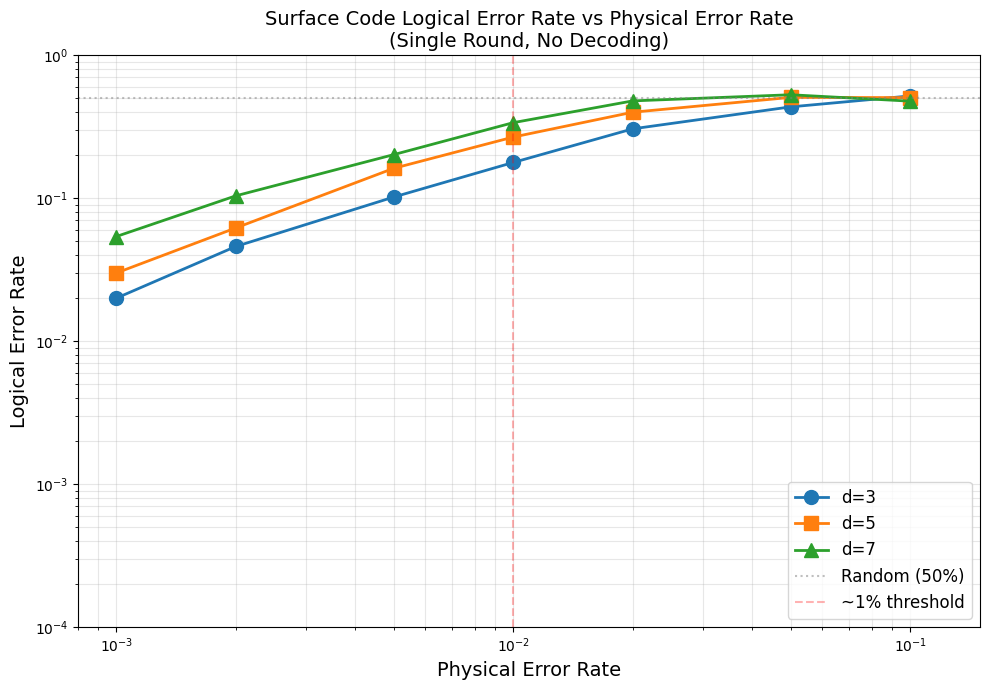

In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 7))

colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]
markers = ["o", "s", "^"]

for i, d in enumerate(distances):
    d_results = [(p, ler) for (dd, p, ler) in results if dd == d]
    ps, lers = zip(*d_results, strict=False)

    # Replace zeros with small value for log scale
    lers = [max(ler, 1e-4) for ler in lers]

    ax.plot(ps, lers, f"{markers[i]}-", color=colors[i],
            label=f"d={d}", markersize=10, linewidth=2)

# Reference lines
ax.axhline(y=0.5, color="gray", linestyle=":", alpha=0.5, label="Random (50%)")
ax.axvline(x=0.01, color="red", linestyle="--", alpha=0.3, label="~1% threshold")

ax.set_xlabel("Physical Error Rate", fontsize=14)
ax.set_ylabel("Logical Error Rate", fontsize=14)
ax.set_title("Surface Code Logical Error Rate vs Physical Error Rate\n(Single Round, No Decoding)", fontsize=14)
ax.set_xscale("log")
ax.set_yscale("log")
ax.legend(fontsize=12, loc="lower right")
ax.grid(True, alpha=0.3, which="both")
ax.set_xlim(0.0008, 0.15)
ax.set_ylim(1e-4, 1.0)

plt.tight_layout()
plt.show()

## Part 4: Analysis

**Important**: Without decoding, larger distance gives *higher* logical error rates!
This is because more qubits = more chances for errors to corrupt the logical state.

The surface code's error suppression comes from the **decoder**, not just the code structure.
With proper MWPM decoding:
- Below threshold: larger distance gives lower logical error rate
- Above threshold: larger distance doesn't help
- Threshold (~1%): curves cross

In [8]:
# Compare distances at specific error rates
print("=== Distance Comparison ===")
print()

for p in [0.001, 0.005, 0.01, 0.02]:
    print(f"p = {p}:")
    for d in distances:
        ler = next((ler for (dd, pp, ler) in results if dd == d and pp == p), None)
        if ler is not None:
            print(f"  d={d}: LER = {ler:.4f}")
    print()

=== Distance Comparison ===

p = 0.001:
  d=3: LER = 0.0200
  d=5: LER = 0.0300
  d=7: LER = 0.0540

p = 0.005:
  d=3: LER = 0.1020
  d=5: LER = 0.1620
  d=7: LER = 0.2020

p = 0.01:
  d=3: LER = 0.1780
  d=5: LER = 0.2680
  d=7: LER = 0.3380

p = 0.02:
  d=3: LER = 0.3060
  d=5: LER = 0.4000
  d=7: LER = 0.4800



## Part 5: Decoding with Multiple Backends

The `SurfaceDecoder` class supports multiple decoder backends, all via Rust bindings in `pecos_rslib.decoders`:

**MWPM Decoders** (space-time matching):
- `pymatching`: Fast C++ MWPM via PyMatching library
- `fusion_blossom`: Pure Rust MWPM implementation

**LDPC Decoders** (belief propagation):
- `bp_osd`: Belief Propagation + Ordered Statistics Decoding
- `bp_lsd`: Belief Propagation + Localized Statistics Decoding  
- `union_find`: Cluster-based decoder

**Search-based Decoders**:
- `tesseract`: A* search with pruning heuristics (requires circuit-level DEM)

**Important note on single-round vs multi-round decoding:**
- With **single round**, the decoder cannot distinguish data errors from measurement errors
- With **multiple rounds**, temporal correlations help identify measurement errors
- MWPM and Tesseract decoders benefit most from multiple rounds (space-time matching)
- LDPC decoders work per-round but can still leverage syndrome history

In [9]:
# Run decoded simulation with multiple syndrome rounds
# Using d rounds is common practice for circuit-level noise
DECODE_ROUNDS = 3  # Multiple rounds for better temporal information

decoded_results = []

print(f"=== Decoded Simulation (PyMatching MWPM, {DECODE_ROUNDS} rounds) ===")
test_error_rates = [0.001, 0.002, 0.005, 0.01]

for d in distances:
    print(f"\nDistance {d}:")
    for p in test_error_rates:
        error_model = DepolarizingErrorModel(
            p_1q=p, p_2q=p, p_meas=p, p_init=p,
        )

        result = run_memory_experiment(
            distance=d,
            num_rounds=DECODE_ROUNDS,
            num_shots=NUM_SHOTS,
            basis=BASIS,
            error_model=error_model,
            decode=True,
            decoder_type="pymatching",
        )

        decoded_results.append((d, p, result["logical_error_rate"], result["raw_error_rate"]))
        print(f"  p={p:.3f}: Decoded LER={result['logical_error_rate']:.3f}, "
              f"Raw LER={result['raw_error_rate']:.3f}")

=== Decoded Simulation (PyMatching MWPM, 3 rounds) ===

Distance 3:


  p=0.001: Decoded LER=0.046, Raw LER=0.046


  p=0.002: Decoded LER=0.074, Raw LER=0.074


  p=0.005: Decoded LER=0.198, Raw LER=0.198


  p=0.010: Decoded LER=0.364, Raw LER=0.364

Distance 5:


...

  p=0.010: Decoded LER=0.420, Raw LER=0.420

Distance 7:


  p=0.001: Decoded LER=0.144, Raw LER=0.144


  p=0.002: Decoded LER=0.236, Raw LER=0.236


  p=0.005: Decoded LER=0.374, Raw LER=0.374


  p=0.010: Decoded LER=0.490, Raw LER=0.490


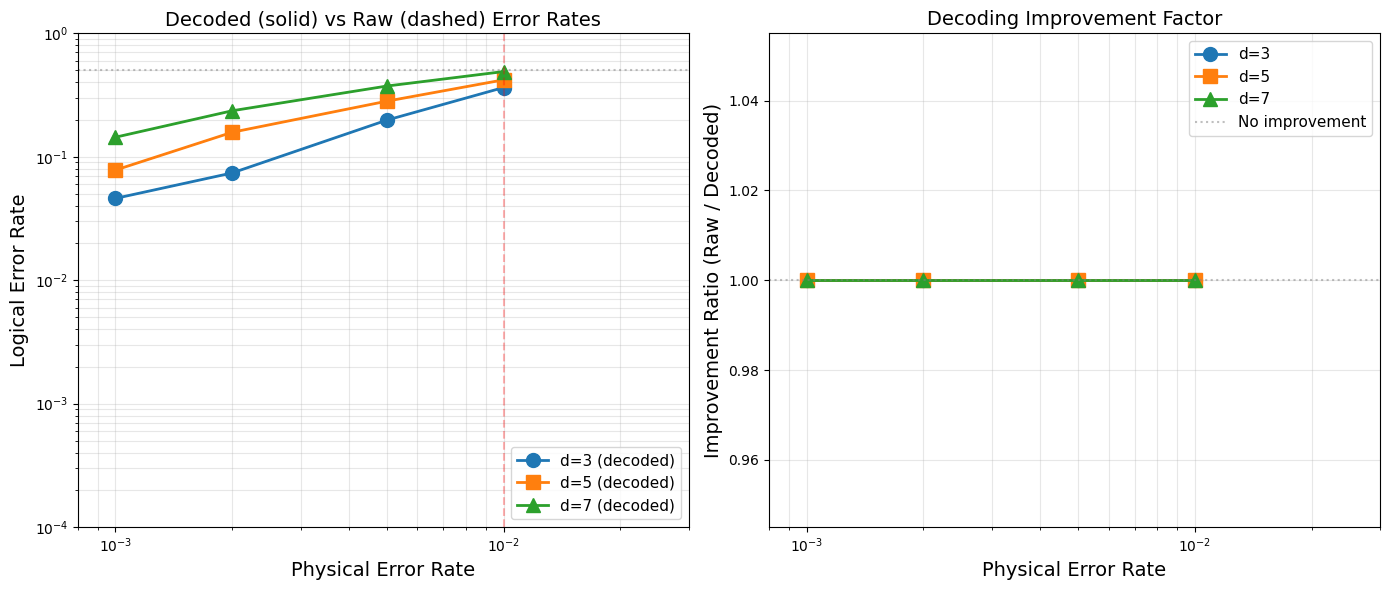

In [10]:
# Compare decoded vs raw error rates
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]
markers = ["o", "s", "^"]

# Left plot: Raw vs Decoded for each distance
for i, d in enumerate(distances):
    d_results = [(p, dec_ler, raw_ler) for (dd, p, dec_ler, raw_ler) in decoded_results if dd == d]
    if d_results:
        ps, dec_lers, raw_lers = zip(*d_results, strict=False)

        # Decoded
        dec_lers_plot = [max(ler, 1e-4) for ler in dec_lers]
        ax1.plot(ps, dec_lers_plot, f"{markers[i]}-", color=colors[i],
                label=f"d={d} (decoded)", markersize=10, linewidth=2)

        # Raw (dashed)
        raw_lers_plot = [max(ler, 1e-4) for ler in raw_lers]
        ax1.plot(ps, raw_lers_plot, f"{markers[i]}--", color=colors[i],
                alpha=0.5, markersize=8, linewidth=1)

ax1.axhline(y=0.5, color="gray", linestyle=":", alpha=0.5)
ax1.axvline(x=0.01, color="red", linestyle="--", alpha=0.3)
ax1.set_xlabel("Physical Error Rate", fontsize=14)
ax1.set_ylabel("Logical Error Rate", fontsize=14)
ax1.set_title("Decoded (solid) vs Raw (dashed) Error Rates", fontsize=14)
ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.legend(fontsize=11, loc="lower right")
ax1.grid(True, alpha=0.3, which="both")
ax1.set_xlim(0.0008, 0.03)
ax1.set_ylim(1e-4, 1.0)

# Right plot: Improvement ratio
for i, d in enumerate(distances):
    d_results = [(p, dec_ler, raw_ler) for (dd, p, dec_ler, raw_ler) in decoded_results if dd == d]
    if d_results:
        ps, dec_lers, raw_lers = zip(*d_results, strict=False)

        # Improvement ratio (raw / decoded)
        ratios = [raw / max(dec, 1e-6) if dec > 0 else 1.0
                  for raw, dec in zip(raw_lers, dec_lers, strict=False)]
        ax2.plot(ps, ratios, f"{markers[i]}-", color=colors[i],
                label=f"d={d}", markersize=10, linewidth=2)

ax2.axhline(y=1.0, color="gray", linestyle=":", alpha=0.5, label="No improvement")
ax2.set_xlabel("Physical Error Rate", fontsize=14)
ax2.set_ylabel("Improvement Ratio (Raw / Decoded)", fontsize=14)
ax2.set_title("Decoding Improvement Factor", fontsize=14)
ax2.set_xscale("log")
ax2.legend(fontsize=11, loc="upper right")
ax2.grid(True, alpha=0.3, which="both")
ax2.set_xlim(0.0008, 0.03)

plt.tight_layout()
plt.show()

## Part 6: Comparing Decoder Backends

Let's compare the different decoder backends on the same noise model.

In [11]:
# Compare different decoder backends
# Note: Tesseract requires circuit-level DEMs (which SurfaceDecoder uses by default)
decoder_types = ["pymatching", "fusion_blossom", "bp_osd", "tesseract"]
compare_distance = 3
compare_rounds = 3
compare_shots = 200
compare_error_rates = [0.001, 0.005, 0.01]

decoder_comparison = {dt: [] for dt in decoder_types}

print(f"=== Decoder Comparison (d={compare_distance}, {compare_rounds} rounds) ===\n")

for p in compare_error_rates:
    print(f"p = {p}:")
    error_model = DepolarizingErrorModel(p_1q=p, p_2q=p, p_meas=p, p_init=p)

    for dt in decoder_types:
        result = run_memory_experiment(
            distance=compare_distance,
            num_rounds=compare_rounds,
            num_shots=compare_shots,
            basis=BASIS,
            error_model=error_model,
            decode=True,
            decoder_type=dt,
        )
        decoder_comparison[dt].append((p, result["logical_error_rate"]))
        print(f"  {dt:15s}: LER = {result['logical_error_rate']:.3f}")
    print()

=== Decoder Comparison (d=3, 3 rounds) ===

p = 0.001:


  pymatching     : LER = 0.045


  fusion_blossom : LER = 0.045


  bp_osd         : LER = 0.060


  tesseract      : LER = 0.070

p = 0.005:


...

  tesseract      : LER = 0.265

p = 0.01:


  pymatching     : LER = 0.330


  fusion_blossom : LER = 0.350


  bp_osd         : LER = 0.295


  tesseract      : LER = 0.365



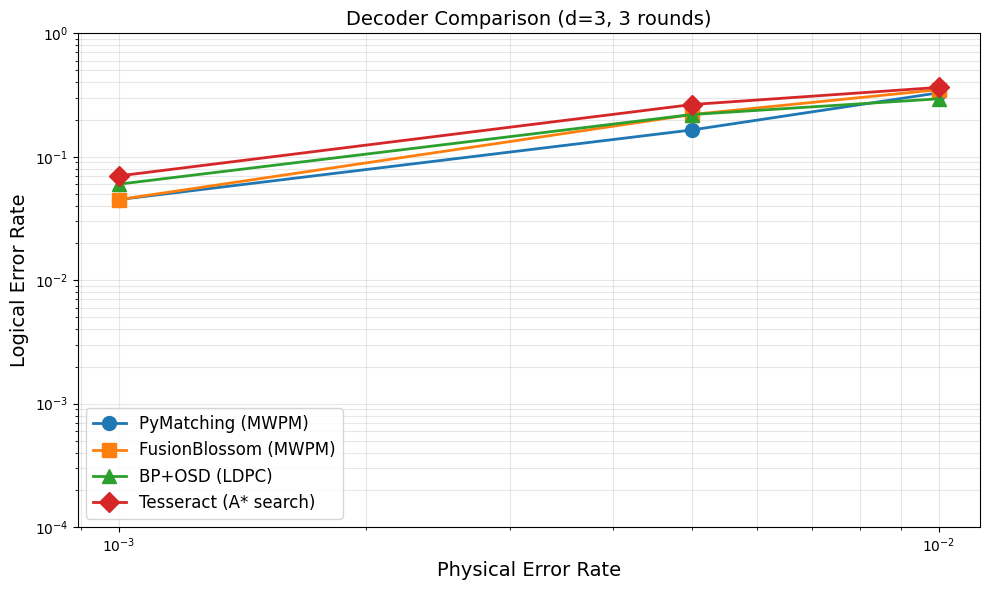

In [12]:
# Plot decoder comparison
fig, ax = plt.subplots(figsize=(10, 6))

colors = {"pymatching": "#1f77b4", "fusion_blossom": "#ff7f0e", "bp_osd": "#2ca02c", "tesseract": "#d62728"}
markers = {"pymatching": "o", "fusion_blossom": "s", "bp_osd": "^", "tesseract": "D"}
labels = {
    "pymatching": "PyMatching (MWPM)",
    "fusion_blossom": "FusionBlossom (MWPM)",
    "bp_osd": "BP+OSD (LDPC)",
    "tesseract": "Tesseract (A* search)",
}

for dt in decoder_types:
    if decoder_comparison[dt]:
        ps, lers = zip(*decoder_comparison[dt], strict=False)
        lers_plot = [max(ler, 1e-4) for ler in lers]
        ax.plot(ps, lers_plot, f"{markers[dt]}-", color=colors[dt],
                label=labels[dt], markersize=10, linewidth=2)

ax.set_xlabel("Physical Error Rate", fontsize=14)
ax.set_ylabel("Logical Error Rate", fontsize=14)
ax.set_title(f"Decoder Comparison (d={compare_distance}, {compare_rounds} rounds)", fontsize=14)
ax.set_xscale("log")
ax.set_yscale("log")
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3, which="both")
ax.set_ylim(1e-4, 1.0)

plt.tight_layout()
plt.show()

## Part 7: PECOS Native DEM Generation

The `SurfaceDecoder` uses PECOS native fault propagation for circuit-level DEM generation:

```
TickCircuit -> DagCircuit -> DagFaultAnalyzer -> DemBuilder -> DEM
```

This provides proper circuit-level noise modeling that accounts for:
- Error propagation through CNOT gates
- Hook errors from the syndrome extraction circuit
- Correlated errors from multi-qubit gates

The DEMs can be exported for use with any decoder or for analysis.

In [13]:
# Generate and inspect DEMs using PECOS native fault propagation
#
# The pipeline: TickCircuit -> DagCircuit -> DagFaultAnalyzer -> DemBuilder -> DEM
#
# This uses backward fault propagation through the circuit to determine which
# fault locations (errors) can flip which detectors and observables.

from pecos.qec.surface import generate_tick_circuit_from_patch
from pecos.qec.surface.circuit_builder import _extract_measurement_order
from pecos_rslib.qec import DagFaultAnalyzer, DemBuilder

# Create a decoder configuration
patch = SurfacePatch.create(distance=3)
noise = NoiseModel(p1=0.001, p2=0.01, p_meas=0.01, p_prep=0.001)

# Generate DEM using PECOS native pipeline
tc = generate_tick_circuit_from_patch(patch, num_rounds=3, basis="Z")
dag = tc.to_dag_circuit()
analyzer = DagFaultAnalyzer(dag)
influence_map = analyzer.build_influence_map()

# Extract metadata from TickCircuit
detectors_json = tc.get_meta("detectors")
observables_json = tc.get_meta("observables")
num_measurements = int(tc.get_meta("num_measurements") or "0")
measurement_order = _extract_measurement_order(tc)

# Build DEM
builder = DemBuilder(influence_map)
builder.with_noise(noise.p1, noise.p2, noise.p_meas, noise.p_prep)
builder.with_num_measurements(num_measurements)
builder.with_measurement_order(measurement_order)
builder.with_detectors_json(detectors_json)
if observables_json:
    builder.with_tracked_paulis_json(observables_json)

pecos_dem = builder.build()

print("=== PECOS Native DEM Generation ===")
print(f"Detectors: {pecos_dem.num_detectors}")
print(f"Error mechanisms: {pecos_dem.num_contributions}")
print(f"Observables: {pecos_dem.num_observables}")
print()
print("DEM preview (first 15 lines):")
for line in pecos_dem.to_string().split("\n")[:15]:
    print(f"  {line}")

=== PECOS Native DEM Generation ===
Detectors: 24
Error mechanisms: 1094
Observables: 1

DEM preview (first 15 lines):
  detector(0, 0, 1) D0
  detector(1, 0, 1) D1
  detector(2, 0, 1) D2
  detector(3, 0, 1) D3
  detector(0, 0, 2) D4
  detector(1, 0, 2) D5
  detector(2, 0, 2) D6
  detector(3, 0, 2) D7
  detector(4, 1, 0) D8
  detector(5, 1, 0) D9
  detector(6, 1, 0) D10
  detector(7, 1, 0) D11
  detector(4, 1, 1) D12
  detector(5, 1, 1) D13
  detector(6, 1, 1) D14


In [14]:
# DEMs can be used with various decoders
# Example: Create a Tesseract decoder (A* search-based) from our PECOS DEM

from pecos_rslib.decoders import TesseractDecoder

# Generate a DEM for d=5
patch5 = SurfacePatch.create(distance=5)

# Use SurfaceDecoder which internally uses PECOS native DEM generation
decoder5 = SurfaceDecoder(patch5, num_rounds=5, noise=noise)
dem_z = decoder5.get_dem(basis="Z")

print(f"DEM size: {len(dem_z)} bytes, {len(dem_z.splitlines())} lines")
print()

# Create Tesseract decoder from DEM
# Note: Tesseract doesn't support standalone 'logical_observable' instructions
# (the observable info is encoded in error edges via L0 references)
dem_for_tesseract = "\n".join(
    line for line in dem_z.splitlines()
    if not line.startswith("logical_observable")
)
tesseract = TesseractDecoder.from_dem(dem_for_tesseract, preset="fast")
print(f"Tesseract decoder: {tesseract}")
print()

# The DEM can also be used with:
# - PyMatching: PyMatchingDecoder.from_dem(dem)
# - Stim: stim.DetectorErrorModel(dem)
# - External tools: Save to file and load

# Example decode with empty syndrome (no errors)
result = tesseract.decode([])  # No detectors fired
print(f"Empty syndrome decode: observables_mask={result.observables_mask}, cost={result.cost}")

# Example decode with some detection events
result = tesseract.decode([0, 8])  # Detectors 0 and 8 fired
print(f"Detectors [0,8] fired: observables_mask={result.observables_mask}, cost={result.cost}")

DEM size: 49453 bytes, 1800 lines

Tesseract decoder: TesseractDecoder(detectors=120, errors=1679, observables=1)

Empty syndrome decode: observables_mask=0, cost=0.0
Detectors [0,8] fired: observables_mask=0, cost=7.4810164852089


## Part 8: Unified Circuit Generation

PECOS provides a unified circuit builder that generates equivalent circuits in multiple formats:
- **Guppy**: High-level quantum DSL for compilation to HUGR
- **Stim**: Circuit format with built-in noise and DEM generation
- **TickCircuit**: Tick-based format with rich metadata
- **DagCircuit**: DAG representation for analysis

All formats are generated from the same underlying circuit description, ensuring consistency.

In [15]:
import json

from pecos.qec.surface import (
    SurfacePatch,
    generate_dag_circuit_from_patch,
    generate_guppy_from_patch,
    generate_stim_from_patch,
    generate_tick_circuit_from_patch,
)

# Create a d=3 patch
patch = SurfacePatch.create(distance=3)
num_rounds = 2
basis = "Z"

In [16]:
# Generate circuits in all formats
guppy_code = generate_guppy_from_patch(patch)
stim_circuit = generate_stim_from_patch(patch, num_rounds, basis)
tick_circuit = generate_tick_circuit_from_patch(patch, num_rounds, basis)
dag_circuit = generate_dag_circuit_from_patch(patch, num_rounds, basis)

# Compare gate counts
print("=== Circuit Comparison ===")
print(f"Guppy: {len(guppy_code)} characters of source code")
print(f"Stim: {len(stim_circuit.splitlines())} lines")
print(f"TickCircuit: {tick_circuit.num_ticks()} ticks, {tick_circuit.gate_count()} gates")
print(f"DagCircuit: {dag_circuit.gate_count()} gates")
print()

# Detailed gate counts from TickCircuit
print("Gate counts (TickCircuit):")
for gate_type, count in tick_circuit.gate_counts_by_type().items():
    print(f"  {gate_type}: {count}")

=== Circuit Comparison ===
Guppy: 4400 characters of source code
Stim: 167 lines
TickCircuit: 18 ticks, 114 gates
DagCircuit: 114 gates

Gate counts (TickCircuit):
  H: 16
  CX: 48
  Measure: 25
  Prep: 8
  QAlloc: 17


### TickCircuit Metadata

TickCircuit stores rich metadata at three levels:
- **Circuit-level**: Detector/observable annotations, basis, measurement counts
- **Tick-level**: Phase (prep, syndrome, measure), round number, CX round
- **Gate-level**: Labels for allocations/measurements, stabilizer info for CX gates

In [17]:
# Circuit-level metadata
print("=== Circuit-Level Metadata ===")
print(f"Basis: {tick_circuit.get_meta('basis')}")
print(f"Num measurements: {tick_circuit.get_meta('num_measurements')}")
print(f"Num detectors: {tick_circuit.get_meta('num_detectors')}")
print()

# Detector annotations (like Stim's DETECTOR)
detectors = json.loads(tick_circuit.get_meta("detectors"))
print(f"Detectors ({len(detectors)} total):")
for det in detectors[:4]:
    print(f"  D{det['id']}: coords={det['coords']}, records={det['records']}")
if len(detectors) > 4:
    print(f"  ... ({len(detectors) - 4} more)")

=== Circuit-Level Metadata ===
Basis: Z
Num measurements: 25
Num detectors: 16

Detectors (16 total):
  D0: coords=[0, 0, 1], records=[-17, -25]
  D1: coords=[1, 0, 1], records=[-16, -24]
  D2: coords=[2, 0, 1], records=[-15, -23]
  D3: coords=[3, 0, 1], records=[-14, -22]
  ... (12 more)


In [18]:
# Tick-level metadata
print("=== Tick-Level Metadata ===")
for i in range(min(10, tick_circuit.num_ticks())):
    phase = tick_circuit.get_tick_meta(i, "phase")
    syn_round = tick_circuit.get_tick_meta(i, "syndrome_round")
    cx_round = tick_circuit.get_tick_meta(i, "cx_round")
    tick = tick_circuit.get_tick(i)

    info = f"Tick {i:2d}: phase={phase:20s}"
    if syn_round is not None:
        info += f", round={syn_round}"
    if cx_round is not None:
        info += f", cx={cx_round}"
    info += f", gates={len(tick)}"
    print(info)

=== Tick-Level Metadata ===
Tick  0: phase=prep_data           , gates=9
Tick  1: phase=syndrome_prep       , round=0, gates=8
Tick  2: phase=syndrome_h_pre      , round=0, gates=4
Tick  3: phase=cx_round_1          , round=0, cx=1, gates=6
Tick  4: phase=cx_round_2          , round=0, cx=2, gates=6
Tick  5: phase=cx_round_3          , round=0, cx=3, gates=6
Tick  6: phase=cx_round_4          , round=0, cx=4, gates=6
Tick  7: phase=syndrome_h_post     , round=0, cx=4, gates=4
Tick  8: phase=measure_ancilla     , round=0, cx=4, gates=8
Tick  9: phase=syndrome_prep       , round=1, gates=8


In [19]:
# Gate-level metadata
print("=== Gate-Level Metadata ===")

# Data qubit allocations (tick 0)
print("\nTick 0 (data allocation):")
for gate_idx in range(min(5, len(tick_circuit.get_tick(0)))):
    label = tick_circuit.get_gate_meta(0, gate_idx, "label")
    print(f"  Gate {gate_idx}: label={label}")

# CX gates with stabilizer info (tick 4 = CX round 1 of syndrome round 0)
cx_tick = 4  # Adjust based on circuit structure
print(f"\nTick {cx_tick} (CX round):")
for gate_idx in range(min(6, len(tick_circuit.get_tick(cx_tick)))):
    stab = tick_circuit.get_gate_meta(cx_tick, gate_idx, "stabilizer")
    print(f"  Gate {gate_idx}: stabilizer={stab}")

# Measurements (last few ticks)
meas_tick = tick_circuit.num_ticks() - 2  # Ancilla measurements
print(f"\nTick {meas_tick} (ancilla measurements):")
for gate_idx in range(min(8, len(tick_circuit.get_tick(meas_tick)))):
    label = tick_circuit.get_gate_meta(meas_tick, gate_idx, "label")
    print(f"  Gate {gate_idx}: label={label}")

=== Gate-Level Metadata ===

Tick 0 (data allocation):
  Gate 0: label=data[0]
  Gate 1: label=data[1]
  Gate 2: label=data[2]
  Gate 3: label=data[3]
  Gate 4: label=data[4]

Tick 4 (CX round):
  Gate 0: stabilizer=Z0
  Gate 1: stabilizer=X1
  Gate 2: stabilizer=Z1
  Gate 3: stabilizer=X2
  Gate 4: stabilizer=Z2
  Gate 5: stabilizer=X3

Tick 16 (ancilla measurements):
  Gate 0: label=sx0
  Gate 1: label=sx1
  Gate 2: label=sx2
  Gate 3: label=sx3
  Gate 4: label=sz0
  Gate 5: label=sz1
  Gate 6: label=sz2
  Gate 7: label=sz3


### Comparison: Stim-based DEM Generation

For comparison, you can also generate DEMs directly via Stim's built-in circuit generator.
This is useful for validation and for cases where you want to use Stim's noise model directly.

In [20]:
import stim

# Generate noisy Stim circuit directly
noisy_stim = generate_stim_from_patch(
    patch,
    num_rounds=3,
    basis="Z",
    p1=0.001,      # Single-qubit gate error
    p2=0.01,       # Two-qubit gate error
    p_meas=0.01,   # Measurement error
    p_prep=0.001,  # Initialization error
)

# Parse and generate DEM
circuit = stim.Circuit(noisy_stim)
dem = circuit.detector_error_model()

print("=== Stim Circuit Statistics ===")
print(f"Circuit instructions: {len(circuit)}")
print(f"DEM detectors: {dem.num_detectors}")
print(f"DEM observables: {dem.num_observables}")
print(f"DEM error mechanisms: {len([i for i in dem if i.type == 'error'])}")
print()

# Show first few lines of the DEM
print("DEM preview:")
for line in str(dem).split("\n")[:10]:
    print(f"  {line}")

=== Stim Circuit Statistics ===
Circuit instructions: 368
DEM detectors: 24
DEM observables: 1
DEM error mechanisms: 221

DEM preview:
  error(0.018131871822544679) D0
  error(0.004005357180252827609) D0 D1
  error(0.0006697986788568588423) D0 D1 D13 D14
  error(0.002006705456917235505) D0 D1 D13 D17
  error(0.002673815958446297981) D0 D1 D13 L0
  error(0.0006697986788568588423) D0 D1 D14 D17
  error(0.0006697986788568588423) D0 D1 D15 D17
  error(0.0006697986788568588423) D0 D1 D15 L0
  error(0.002006705456917235505) D0 D1 D17 L0
  error(0.0148913139762814218) D0 D4


## Summary

This notebook demonstrated:

1. **Surface code circuits**: Generated using `make_surface_code()` from `pecos.guppy.surface`
2. **Noisy simulation**: Using `DepolarizingErrorModel` from `selene_sim`
3. **Raw error measurement**: Checking parity of logical operator qubits (no decoding)
4. **Multiple decoders**: All via Rust bindings in `pecos_rslib.decoders`:
   - PyMatching (C++ MWPM)
   - FusionBlossom (Rust MWPM)
   - BP+OSD (Belief Propagation + Ordered Statistics Decoding)
   - Tesseract (A* search-based decoder)
5. **PECOS native DEM generation**: Circuit-level fault propagation without external dependencies
6. **Unified circuit generation**: Generate equivalent circuits in multiple formats

**Key findings**:
- Without decoding, larger distance = more logical errors (more qubits to corrupt)
- With MWPM decoding and multiple syndrome rounds, error correction becomes effective
- Single-round experiments are limited because the decoder can't distinguish data vs measurement errors
- For proper threshold studies, use at least d syndrome rounds

**PECOS native DEM generation pipeline**:
```python
from pecos.qec.surface import generate_tick_circuit_from_patch
from pecos_rslib.qec import DagFaultAnalyzer, DemBuilder

# Generate TickCircuit (matches Guppy circuit structure)
tc = generate_tick_circuit_from_patch(patch, num_rounds=3, basis="Z")

# Build influence map via Rust fault propagation
dag = tc.to_dag_circuit()
analyzer = DagFaultAnalyzer(dag)
influence_map = analyzer.build_influence_map()

# Construct DEM
builder = DemBuilder(influence_map)
builder.with_noise(p1, p2, p_meas, p_prep)
builder.with_detectors_json(tc.get_meta("detectors"))
dem = builder.build()

# Use with any decoder
dem_string = dem.to_string()
```

**TickCircuit metadata**:
```python
# Circuit-level: detectors, observables, basis
tick.get_meta('detectors')  # JSON array of detector annotations

# Tick-level: phase, syndrome_round, cx_round
tick.get_tick_meta(0, 'phase')  # 'prep_data', 'cx_round_1', etc.

# Gate-level: labels and stabilizer info
tick.get_gate_meta(0, 0, 'label')      # 'data[0]', 'sx0', 'final[0]'
tick.get_gate_meta(4, 0, 'stabilizer') # 'X0', 'Z2'
```

**Decoder selection**:
```python
# PyMatching (default, recommended for most cases)
decoder = SurfaceDecoder(patch, num_rounds=3, decoder_type="pymatching")

# FusionBlossom (pure Rust alternative)
decoder = SurfaceDecoder(patch, num_rounds=3, decoder_type="fusion_blossom")

# BP+OSD (LDPC decoder, good for general codes)
decoder = SurfaceDecoder(patch, num_rounds=3, decoder_type="bp_osd")

# Tesseract (A* search, uses PECOS native DEM)
decoder = SurfaceDecoder(patch, num_rounds=3, decoder_type="tesseract")
```

**DEM usage**:
```python
# Get DEM from SurfaceDecoder (uses PECOS native generation)
dem = decoder.get_dem(basis="Z")

# Create decoders directly from DEM
from pecos_rslib.decoders import PyMatchingDecoder, TesseractDecoder

pymatching = PyMatchingDecoder.from_dem(dem)
tesseract = TesseractDecoder.from_dem(dem, preset="fast")
```

**Noise model**:
```python
noise = NoiseModel(
    p1=0.001,      # Single-qubit gate error rate
    p2=0.01,       # Two-qubit gate error rate
    p_meas=0.01,   # Measurement error rate
    p_prep=0.001,  # Initialization error rate
)
```